#### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.

In [5]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

In [6]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm.invoke("hi, how are you?")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hi, how are you?"\n   - This is a standard greeting and polite inquiry about my well-being.\n\n2.  **Identify Key Components:**\n   - Greeting: "hi"\n   - Question: "how are you?"\n   - Tone: Casual, friendly\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting\n   - Respond to the question appropriately (as an AI, I don\'t have feelings, but I can express readiness to help)\n   - Keep it friendly and conversational\n   - Turn the conversation back to the user to encourage engagement\n\n4.  **Draft Response (Mental):**\n   Hi! I\'m doing well, thanks for asking. I\'m here and ready to help you with whatever you need. How are you doing today?\n\n5.  **Refine Response (Self-Correction/Verification):**\n   - Check tone: Friendly, appropriate\n   - Check accuracy: Acknowledges AI nature implicitly by focusing on readiness to help\n   - Check engagement: Asks a follow

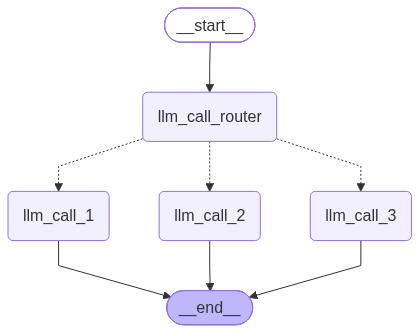

In [7]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict


class Route(BaseModel):
    step:Literal["poem", "story", "joke"]=Field(description="The next step in the routing process")

router = llm.with_structured_output(Route)

class State(TypedDict):
    input:str
    decision:str
    output:str

def llm_call_1(state:State):
     """Write a story"""
     msg = llm.invoke(state["input"])
     return {"output": msg.content}

def llm_call_2(state:State):
    """Write a joke"""
    msg=llm.invoke(state["input"])
    return {"output": msg.content}

def llm_call_3(state:State):
    """Write a poem"""
    msg=llm.invoke(state["input"])
    return {"output":msg.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""
    decision = router.invoke([
            SystemMessage(
                content="Route the input to story,joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"])
        ])
    return {"decision":decision.step}

def route_decision(state:State):
    if state["decision"] == "story":
        return "llm_call_1"
    if state["decision"] == "joke":
        return "llm_call_2"
    if state["decision"] == "poem":
        return "llm_call_3"

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

router_builder = StateGraph(State)

router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges("llm_call_router", route_decision, {
    "llm_call_1": "llm_call_1",
    "llm_call_2": "llm_call_2",
    "llm_call_3": "llm_call_3"})
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

router_workflow = router_builder.compile()


display(Image(router_workflow.get_graph().draw_mermaid_png()))



In [8]:
state=router_workflow.invoke({"input":"Write me a joke about Agentic AI System"})
print(state["output"])


<think>
Here's a thinking process:

1.  **Analyze User Request:**
   - **Topic:** Agentic AI System
   - **Format:** Joke
   - **Key Concepts:** Agentic AI refers to AI systems that can autonomously plan, execute, and adapt to achieve goals, often using tools, interacting with environments, and making decisions without constant human input.

2.  **Identify Core Themes/Punchline Opportunities:**
   - Autonomy vs. human oversight
   - Goal-oriented behavior
   - Tool use/API integration
   - Self-correction/iteration
   - Over-optimization or literal interpretation
   - "Agent" double meaning (spy, real estate, AI)
   - Planning/execution loops
   - "I'll handle it" attitude

3.  **Brainstorming Joke Structures:**
   - Setup + Punchline
   - Q&A format
   - Story format
   - Pun-based
   - Misdirection

   Let's try a Q&A or setup-punchline format first.

   *Idea 1:* Why did the Agentic AI go to therapy? Because it kept taking things too literally... (weak, not specific enough)
   *Ide